In [ ]:
%matplotlib inline


# Evolution of Players


In [1]:
from urllib.request import urlopen

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
from PIL import Image
from highlight_text import ax_text

from mplsoccer import VerticalPitch, add_image, FontManager, Sbopen

In [54]:
parser = Sbopen()
df_striker = parser.event(18241)[0]  # 0 index is the event file
df_winger = parser.event(9736)[0]  # 0 index is the event file
# filter messi's actions (starting positions)
df_striker = df_striker.loc[df_striker.player_id == 5207, ['x', 'y']]
df_winger = df_winger.loc[df_winger.player_id == 5207, ['x', 'y']]

In [55]:
flamingo_cmap = LinearSegmentedColormap.from_list("Flamingo - 100 colors",
                                                  ['#e3aca7', '#c03a1d'], N=100)

In [56]:
el_greco_yellow_cmap = LinearSegmentedColormap.from_list("El Greco Yellow - 10 colors",
                                                         ['#7c2e2a', '#f2dd44'], N=10)

Cristiano's 2017/18 Striker Role



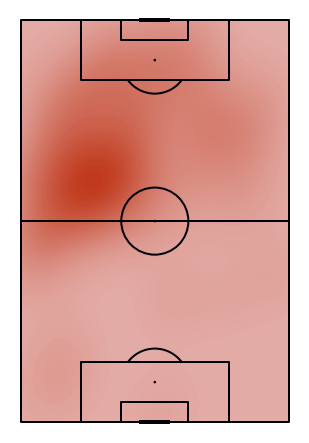

In [57]:
pitch = VerticalPitch(line_color='#000009', line_zorder=2)
fig, ax = pitch.draw(figsize=(4.4, 6.4))
kde = pitch.kdeplot(df_striker.x, df_false9.y, ax=ax,
                    # shade using 100 levels so it looks smooth
                    shade=True, levels=100,
                    # shade the lowest area so it looks smooth
                    # so even if there are no events it gets some color
                    shade_lowest=True,
                    cut=4,  # extended the cut so it reaches the bottom edge
                    cmap=flamingo_cmap)

Load a custom font.



In [58]:
URL = 'https://github.com/google/fonts/blob/main/apache/roboto/Roboto%5Bwdth,wght%5D.ttf?raw=true'
URL2 = 'https://github.com/google/fonts/blob/main/apache/robotoslab/RobotoSlab%5Bwght%5D.ttf?raw=true'
robotto_regular = FontManager(URL)
robboto_bold = FontManager(URL2)

Load images.



In [59]:

cris_photo = 'https://i.imgur.com/VMXPa0B.png'
cris_image = Image.open(urlopen(cris_photo))


Text(0.5, 0.25, '2017/18 Striker Role')

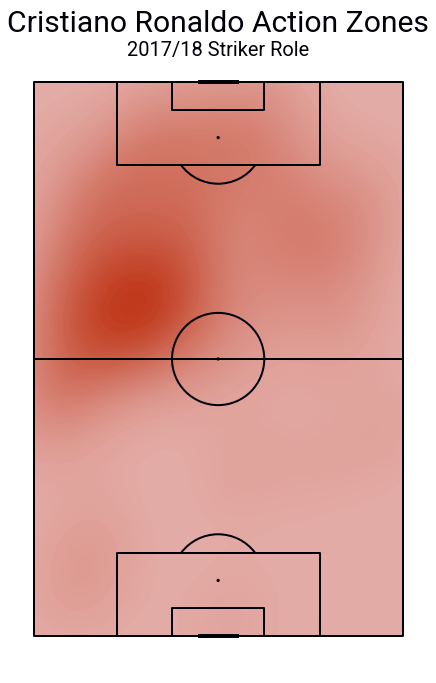

In [61]:
fig, axs = pitch.grid(figheight=10, title_height=0.08, endnote_space=0, title_space=0,
                      axis=False,
                      grid_height=0.82, endnote_height=0.03)
kde = pitch.kdeplot(df_striker.x, df_striker.y, ax=axs['pitch'],
                    # shade using 100 levels so it looks smooth
                    shade=True, levels=100,
                    # shade the lowest area so it looks smooth
                    # so even if there are no events it gets some color
                    shade_lowest=True,
                    cut=4,  # extended the cut so it reaches the bottom edge
                    cmap=flamingo_cmap)

axs['title'].text(0.5, 0.7, "Cristiano Ronaldo Action Zones", color='#000009',
                  va='center', ha='center', fontproperties=robotto_regular.prop, fontsize=30)
axs['title'].text(0.5, 0.25, "2017/18 Striker Role", color='#000009',
                  va='center', ha='center', fontproperties=robotto_regular.prop, fontsize=20)


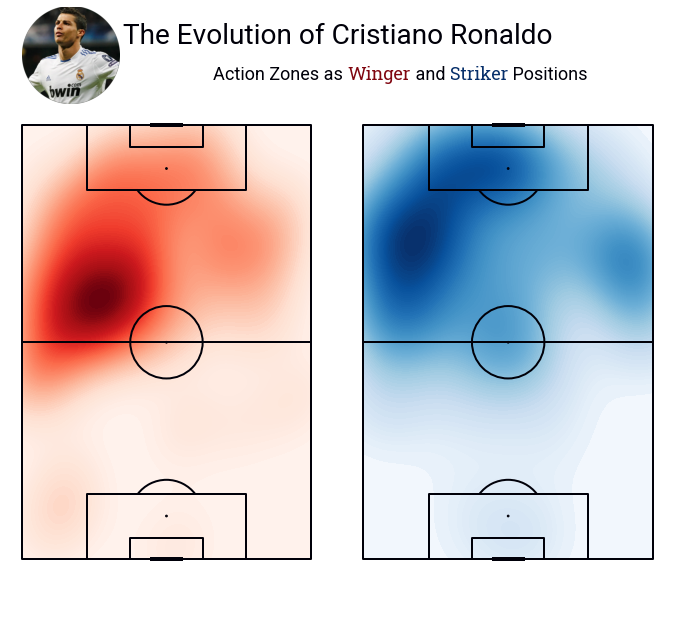

In [65]:
fig, axs = pitch.grid(ncols=2, axis=False, endnote_height=0.05)

kde_before = pitch.kdeplot(df_striker.x, df_striker.y, ax=axs['pitch'][0],
                           shade=True, levels=100, shade_lowest=True,
                           cut=4, cmap='Reds')

kde_after = pitch.kdeplot(df_winger.x, df_winger.y, ax=axs['pitch'][1],
                          shade=True, levels=100, shade_lowest=True,
                          cut=4, cmap='Blues')


ax_messi = add_image(messi_image, fig, interpolation='hanning',
                     # set the left, bottom and height to align with the title
                     left=axs['title'].get_position().x0,
                     bottom=axs['title'].get_position().y0,
                     height=axs['title'].get_position().height)

# titles using highlight_text and a google font (Roboto)

TITLE_STR1 = 'The Evolution of Cristiano Ronaldo'
TITLE_STR2 = 'Action Zones as <Winger> and <Striker> Positions'
title1_text = axs['title'].text(0.5, 0.7, TITLE_STR1, fontsize=28, color='#000009',
                                fontproperties=robotto_regular.prop,
                                ha='center', va='center')
highlight_text = [{'color': '#800610', 'fontproperties': robboto_bold.prop},
                  {'color': '#08306b', 'fontproperties': robboto_bold.prop}]
ax_text(0.6, 0.3, TITLE_STR2, ha='center', va='center', fontsize=18, color='#000009',
        fontproperties=robotto_regular.prop,
        highlight_textprops=highlight_text, ax=axs['title'])



plt.show()  # If you are using a Jupyter notebook you do not need this line
fig.savefig("cris_ev.jpg",dpi=1200)